Train shape: (54214, 4)
Test shape: (54200, 3)

Naive Bayes Validation Accuracy: 0.5098
              precision    recall  f1-score   support

      action       0.67      0.02      0.03       263
       adult       0.50      0.02      0.03       118
   adventure       0.71      0.03      0.06       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.41      0.46      1490
       crime       0.00      0.00      0.00       101
 documentary       0.56      0.91      0.69      2619
       drama       0.45      0.84      0.58      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.03      0.05        39
     history       0.00      0.00      0.00        49
      horror       0.81      0.23      0.35       441
       music       1.00      0.01      0.03       146
     musical       0.00      0.00      0.00    

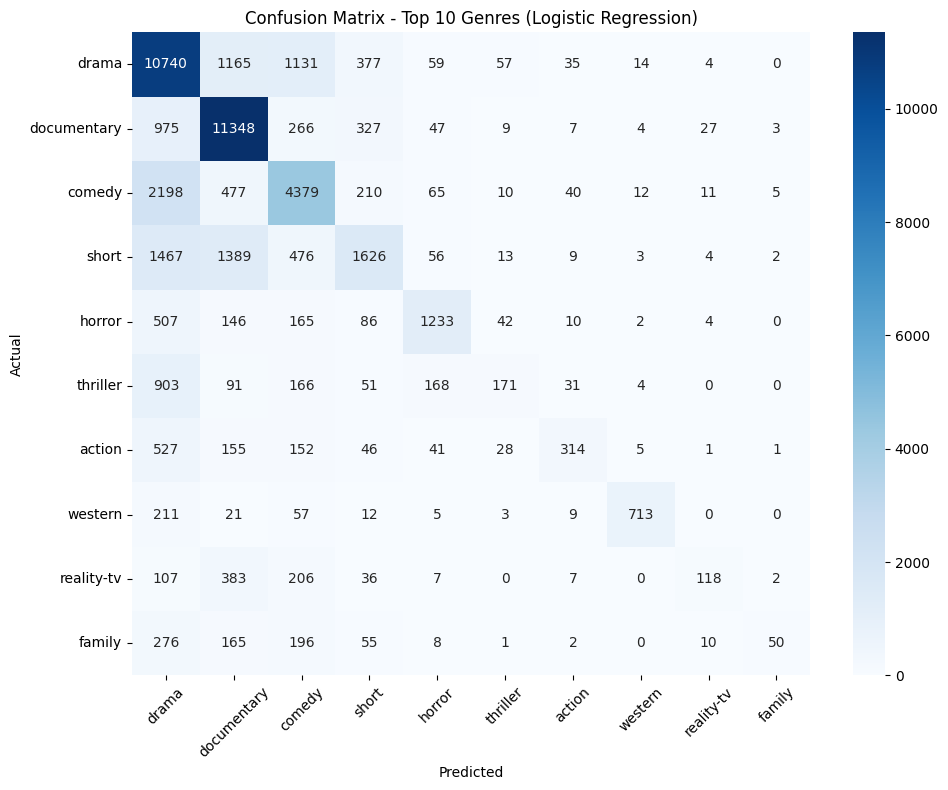


Sample Prediction: fantasy

Task 1 completed successfully!


In [1]:
# =========================================================
# TASK 1: MOVIE GENRE CLASSIFICATION
# CODSOFT Machine Learning Internship
# =========================================================
# Predict movie genre from plot summary using TF-IDF + ML classifiers

# ---------- 1. IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------- 2. LOAD DATASET ----------
train_path = "/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/train_data.txt"
test_path = "/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/test_data.txt"
test_solution_path = "/kaggle/input/datasets/hijest/genre-classification-dataset-imdb/Genre Classification Dataset/test_data_solution.txt"

# NOTE: If you get a FileNotFoundError, run this first to find the EXACT path:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# Then copy the exact paths shown and replace the three lines above.

train_df = pd.read_csv(train_path, sep=":::", engine="python",
                        names=["ID", "TITLE", "GENRE", "DESCRIPTION"])

test_df = pd.read_csv(test_path, sep=":::", engine="python",
                       names=["ID", "TITLE", "DESCRIPTION"])

test_solution_df = pd.read_csv(test_solution_path, sep=":::", engine="python",
                                names=["ID", "TITLE", "GENRE", "DESCRIPTION"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

# ---------- 3. TEXT CLEANING ----------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df["clean_description"] = train_df["DESCRIPTION"].apply(clean_text)
test_df["clean_description"] = test_df["DESCRIPTION"].apply(clean_text)
test_solution_df["clean_description"] = test_solution_df["DESCRIPTION"].apply(clean_text)

# ---------- 4. TARGET ENCODING ----------
train_df["GENRE"] = train_df["GENRE"].str.strip()
test_solution_df["GENRE"] = test_solution_df["GENRE"].str.strip()

# ---------- 5. TF-IDF VECTORIZATION ----------
tfidf = TfidfVectorizer(max_features=15000, stop_words="english", ngram_range=(1, 2))

X_train_full = tfidf.fit_transform(train_df["clean_description"])
y_train_full = train_df["GENRE"]

X_test_final = tfidf.transform(test_solution_df["clean_description"])
y_test_final = test_solution_df["GENRE"]

# ---------- 6. TRAIN-VALIDATION SPLIT (from training data) ----------
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# ---------- 7. MODEL TRAINING & COMPARISON ----------
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(max_iter=2000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    results[name] = acc
    print(f"\n{name} Validation Accuracy: {acc:.4f}")
    print(classification_report(y_val, val_preds, zero_division=0))

# ---------- 8. PICK BEST MODEL & EVALUATE ON TEST SET ----------
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name} (Val Accuracy: {results[best_model_name]:.4f})")

test_preds = best_model.predict(X_test_final)
test_acc = accuracy_score(y_test_final, test_preds)
print(f"\nFinal Test Accuracy ({best_model_name}): {test_acc:.4f}")
print(classification_report(y_test_final, test_preds, zero_division=0))

# ---------- 9. CONFUSION MATRIX (Top 10 Genres) ----------
top_genres = train_df["GENRE"].value_counts().head(10).index
mask = y_test_final.isin(top_genres)

cm = confusion_matrix(y_test_final[mask], pd.Series(test_preds, index=y_test_final.index)[mask],
                       labels=top_genres)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=top_genres, yticklabels=top_genres)
plt.title(f"Confusion Matrix - Top 10 Genres ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_task1.png", dpi=150)
plt.show()

# ---------- 10. TEST ON CUSTOM PLOT SUMMARY ----------
def predict_genre(plot_summary):
    cleaned = clean_text(plot_summary)
    vec = tfidf.transform([cleaned])
    return best_model.predict(vec)[0]

sample_plot = "A young wizard discovers his magical powers and battles an evil dark lord."
print("\nSample Prediction:", predict_genre(sample_plot))

print("\nTask 1 completed successfully!")